# Cài đặt các Thư viện sử dụng

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from underthesea import word_tokenize
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.tree import DecisionTreeClassifier
from keras.metrics import Precision, Recall
import os

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Cài đặt hiển thị dataFrame

In [3]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
# pd.set_option('display.max_colwidth', None)

# Đọc dữ liệu


- vn_news_223_tdlfr.csv là file chứa news cần xử lý
- vietnamese-stopwords.txt chứa các stop word cần xử lý

In [4]:


file = os.path.join("../../Data_Train", "English.csv")
data_df = pd.read_csv(file, encoding = 'utf-8')

In [5]:
model_vector = os.path.join("../../Model/English", "EngLish_vectorizer.joblib")
model_DTC = os.path.join("../../Model/English", "English_DTC_model.joblib")
model_NB = os.path.join("../../Model/English", "English_NB_model.joblib")

# Khám phá dữ liệu

## Mẫu dữ liệu

In [6]:
data_df.sample(5)

,title,text,label
5171,House Republican leader says easier if Session...,WASHINGTON (Reuters) - U.S. House of Represent...,0
15733,Venezuela opposition coalition split ahead of ...,CARACAS/MARACAIBO Venezuela (Reuters) - One of...,0
7628,Clinton says there is no case here in FBI emai...,KENT Ohio (Reuters) - Democratic presidential ...,0
15802,Syrian army takes full control of Deir al-Zor ...,BEIRUT (Reuters) - The Syrian army and its all...,0
13999,Five Ukrainian servicemen killed in eastern Uk...,KIEV (Reuters) - Five Ukrainian servicemen wer...,0


## Xem thông tin

In [7]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39000 entries, 0 to 38999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   39000 non-null  object
 1   text    39000 non-null  object
 2   label   39000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 914.2+ KB


## Xem mô tả

In [8]:
data_df.describe()

,label
count,39000.000000
mean,0.500000
std,0.500006
min,0.000000
25%,0.000000
50%,0.500000
75%,1.000000
max,1.000000


In [9]:
data_df.describe().round(1)

,label
count,39000.0
mean,0.5
std,0.5
min,0.0
25%,0.0
50%,0.5
75%,1.0
max,1.0


## Xem số dòng và số cột của dữ liệu

In [10]:
num_rows=data_df.shape[0]
num_cols=data_df.shape[1]
print(num_rows)
print(num_cols)

39000
3


## ý nghĩa của các dòng

### Kiểm tra dữ liệu có bị lặp ?

In [11]:
dup=data_df.index.duplicated().sum()
dup

0

### ý nghĩa các cột

- text: nội dung của tin tức
- domain: đường dẫn đến trang web chứa tin tức 
- label: nhãn phân biệt tin giả hay tin thật

### Dữ liệu có bị thiếu không?

In [12]:
data_df['title'].isnull().sum()

0

In [13]:
data_df['text'].isnull().sum()

0

In [14]:
data_df['label'].isnull().sum()

0

### Mỗi cột hiện đang có kiểu dữ liệu gì? Có cột nào có kiểu dữ liệu chưa phù hợp để có thể xử lý tiếp không?

In [15]:
data_df.dtypes

title    object
text     object
label     int64
dtype: object

#### Cột có dtype là object nghĩa là sao?

- Trong Pandas, kiểu dữ liệu object thường ám chỉ chuỗi, nhưng thật ra kiểu dữ liệu object có thể chứa một đối tượng bất kỳ trong Python (vì thật ra ở bên dưới kiểu dữ liệu object chứa địa chỉ).
- Nếu một cột trong dataframe có dtype là object thì có thể các phần tử trong cột này sẽ có kiểu dữ liệu khác nhau
- Để biết được kiểu dữ liệu thật sự của các phần tử trong cột này thì ta phải truy xuất vào từng phần tử. Ta muốn xem thử trong nội bộ mỗi cột này có các kiểu dữ liệu nào

In [16]:
def open_object_dtype(s):
    dtypes = set()
    s=s.apply(type)
    dtypes.update(s.unique().tolist())
    return dtypes

In [17]:
open_object_dtype(data_df['title'])

{str}

In [18]:
open_object_dtype(data_df['text'])

{str}

In [19]:
open_object_dtype(data_df['label'])

{int}

#### Kiểm tra phân bố các class có chênh lệch không?

In [20]:
data_df['label'].value_counts(normalize=True) * 100

label
0    50.0
1    50.0
Name: proportion, dtype: float64

Xem phân bố dữ liệu

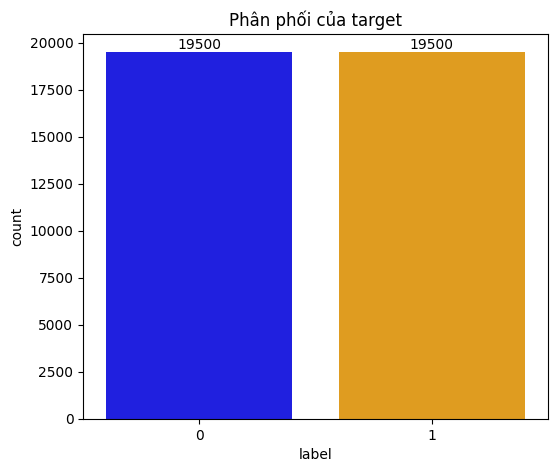

In [21]:
import seaborn as sns
%matplotlib inline
def plot_target(data, title):
    target_counts = data.value_counts('label').reset_index()  # Reset chỉ mục để có dataframe
    target_counts.columns = ['label', 'count']  # Đặt tên cột
    
    plt.figure(figsize=(6,5))
    
    # Vẽ biểu đồ với hue là cột 'label' để không nhận cảnh báo
    ax = sns.barplot(x='label', y='count', hue='label', data=target_counts, 
                     palette={0: 'blue', 1: 'orange'}, legend=False)
    
    ax.set_title(title)
    
    # Hiển thị giá trị của từng cột
    for i in ax.containers:
        ax.bar_label(i)
    
    plt.show()

# Ví dụ sử dụng
plot_target(data_df, 'Phân phối của target')


#### Các thông tin thống kê

##### Chiều dài trung bình mỗi record là bao nhiêu?

In [22]:
len_sum=0
for i in data_df['text']:
    len_sum+=len(i)
len_avg=len_sum/data_df['text'].count()
len_avg

2434.940871794872

##### Record dài nhất là bao nhiêu?

In [23]:
max_len=0
for i in data_df['text']:
    if len(i)>max_len:
        max_len=len(i)
max_len

49071

##### Record ngắn nhất là bao nhiêu?

In [24]:
min_len=len(data_df['text'][0])
for i in data_df['text']:
    if len(i)<min_len:
        min_len=len(i)
min_len

107

### Tiền xử lí văn bản

#### Loại bỏ các đường link và các dấu câu, lowercase

In [25]:
from nltk.corpus import stopwords
import nltk
# nltk.download('stopwords')
# nltk.download('punkt')
#stopwords of NLTK
stopword=list(stopwords.words('english'))

In [26]:
import string
def wordopt(text):

    update_text =""

    text = text.lower()

    text=re.sub("reuters"," ",text)
    
    #simplifying text
    text=re.sub(r"i'm","i am",text)
    text=re.sub(r"he's","he is",text)
    text=re.sub(r"she's","she is",text)
    text=re.sub(r"that's","that is",text)
    text=re.sub(r"what's","what is",text)
    text=re.sub(r"where's","where is",text)
    text=re.sub(r"\'ll"," will",text)
    text=re.sub(r"\'ve"," have",text)
    text=re.sub(r"\'re"," are",text)
    text=re.sub(r"\'d"," would",text)
    text=re.sub(r"won't","will not",text)
    text=re.sub(r"can't","cannot",text)


    text=re.sub(r"[-()\"#!@$%^&*{}?.,:]"," ",text)
    text=re.sub(r"\s+"," ",text)

    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W", " ", text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)

    for word in text.split():
        if word not in stopword:
            update_text+=word+" "
    
    return update_text.strip()


In [27]:
data_df["title"] = data_df["title"].apply(wordopt)
data_df["text"] = data_df["text"].apply(wordopt)

In [28]:
data_df.head()

,title,text,label
0,u budget fight looms republicans flip fiscal s...,washington head conservative republican factio...,0
1,u military accept transgender recruits monday ...,washington transgender people allowed first ti...,0
2,senior u republican senator let mr mueller job,washington special counsel investigation links...,0
3,fbi russia probe helped australian diplomat ti...,washington trump campaign adviser george papad...,0
4,trump wants postal service charge much amazon ...,seattle washington president donald trump call...,0


#### Tokenizer

In [29]:
def tokenize(sentence):
    return word_tokenize(sentence, format = 'word')

In [30]:
vectorization = CountVectorizer(
    stop_words = stopword,
    tokenizer = tokenize,
)

### Mô hình hóa

- Chuyển đoạn văn tiếng Việt về vector, sử dụng CountVectorizer của sklearn
- với các tham số là danh sách stopwords tiếng Việt
- và tokenizer tách từ tiếng Việt

Chia tập dữ liệu thành 2 tập

- Tập train: 75%
- Tập test: 25%


In [31]:
data_df['combined'] = data_df['title'] + ' |title| ' + data_df['text'] + ' |text|'
X = data_df["combined"]
y = data_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25,
                                                   random_state=30)

In [32]:

Xv_train = vectorization.fit_transform(X_train)
Xv_test = vectorization.transform(X_test)

In [33]:
joblib.dump(vectorization, model_vector)

['../../Model/English\\EngLish_vectorizer.joblib']

### Decision Tree

In [34]:
from sklearn.metrics import classification_report

In [35]:
DT = DecisionTreeClassifier()
DT.fit(Xv_train,y_train)

DecisionTreeClassifier()

In [36]:
pred_dt = DT.predict(Xv_test)
print(DT.score(Xv_test, y_test))
print(classification_report(y_test, pred_dt))
#save model Decision Tree
joblib.dump(DT, model_DTC)

0.958974358974359
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      4879
           1       0.95      0.97      0.96      4871

    accuracy                           0.96      9750
   macro avg       0.96      0.96      0.96      9750
weighted avg       0.96      0.96      0.96      9750



['../../Model/English\\English_DTC_model.joblib']

### Naive Bayes

In [37]:
NB = MultinomialNB()
NB.fit(Xv_train,y_train)

MultinomialNB()

In [38]:
pred_nb = NB.predict(Xv_test)
print(NB.score(Xv_test, y_test))
print(classification_report(y_test, pred_dt))
#save model Naive Bayes
joblib.dump(NB, model_NB)

0.9508717948717949
              precision    recall  f1-score   support

           0       0.97      0.95      0.96      4879
           1       0.95      0.97      0.96      4871

    accuracy                           0.96      9750
   macro avg       0.96      0.96      0.96      9750
weighted avg       0.96      0.96      0.96      9750



['../../Model/English\\English_NB_model.joblib']

### Đánh giá mô hình

- Mô hình với Decesion Tree  có độ chính xác cao khoảng 95%
- Mô hình với Naive Bayes có độ chính xác cao khoảng 95%